In [5]:
from confidence_correctness_matrix import *
from ucimlrepo import fetch_ucirepo
from sklearn.naive_bayes import GaussianNB
import numpy as np
from matplotlib import pyplot as plt

## **Class-independent**

**Probabilistic Confusion Matrix**

In [6]:
# Loads the iris dataset
iris  = fetch_ucirepo(id=53)
X, y = iris.data.features, iris.data.targets.squeeze()

classes = np.unique(y)
print(f"Classes: {classes}\n")

np.set_printoptions(suppress=True, formatter={'float': '{: 0.3f}'.format})

# Training and predict
model = GaussianNB().fit(X, y)
y_score = model.predict_proba(X)

# Calculates the probabilistic confusion matrix and the probabilistic metrics
prob_conf_matrix = prob_confusion_matrix(y, y_score, labels=classes)
prob_acc = prob_accuracy_score(y, y_score)
prob_b_acc = prob_balanced_accuracy_score(y, y_score)
prob_prec = prob_precision_score(y, y_score, average="micro")
prob_recall = prob_recall_score(y, y_score, average="macro")
prob_f1 = prob_f1_score(y, y_score, average="weighted")
prob_cohen_kappa = prob_cohen_kappa_score(y, y_score)
prob_m_corrcoef = prob_matthews_corrcoef(y, y_score)

print(f"Probabilistic confusion matrix:\n {prob_conf_matrix}\n")
print(f"Acc* = {prob_acc:.3f}, B_acc* = {prob_b_acc:.3f}, Prec* = {prob_prec:.3f}, MCC* = {prob_m_corrcoef:.3f}, Recall* = {prob_recall:.3f}, F1* = {prob_f1:.3f}, Cohen Kappa* = {prob_cohen_kappa:.3f}\n")

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Probabilistic confusion matrix:
 [[ 50.000  0.000  0.000]
 [ 0.000  46.060  3.940]
 [ 0.000  3.930  46.070]]

Acc* = 0.948, B_acc* = 0.948, Prec* = 0.948, MCC* = 1.000, Recall* = 0.948, F1* = 0.948, Cohen Kappa* = 0.927



**High-confidence and Low-confidence Matrices**

In [7]:
# Calculates the high-confidence and low-confidence matrices and their lambda values
H, L = confidence_matrices(y, y_score)
lambda_H, lambda_L = confidence_weights(y, y_score)

print(f"High-Confidence matrix:\n {H}")
print(f"lambda_H = {lambda_H:.3f}\n")
print(f"Low-Confidence matrix:\n {L}")
print(f"lambda_L = {lambda_L:.3f}\n")

High-Confidence matrix:
 [[ 50.000  0.000  0.000]
 [ 0.000  45.374  2.314]
 [ 0.000  2.644  45.715]]
lambda_H = 0.974

Low-Confidence matrix:
 [[ 0.000  0.000  0.000]
 [ 0.000  0.686  1.626]
 [ 0.000  1.285  0.356]]
lambda_L = 0.026



**Class-independent Confidence-Correctness Matrix**

In [8]:
# Calculates the class-independent Confidence-Correctnes matrix
ci_confCorrM = confidence_correctness_matrix(y, y_score, class_specific=False)
print("Class-independent Confidence-Correctnes matrix values:")
for key, value in ci_confCorrM.items():
    print(f"{key}: {value:.3f}")

Class-independent Confidence-Correctnes matrix values:
Reliability: 0.941
Overconfidence: 0.033
Underconfidence: 0.019
Ambiguity: 0.007


## **Class-specific**

**Class-specific Confident-Correctness Matrix**

In [10]:
# Loads wine-quality the dataset
wine_quality  = fetch_ucirepo(id=186)
X, y = wine_quality.data.features, wine_quality.data.targets.squeeze()

classes = np.unique(y)
print(f"Classes: {classes}\n")

np.set_printoptions(suppress=True, formatter={'float': '{: 0.3f}'.format})

# Training and predict
model = GaussianNB().fit(X, y)
y_score = model.predict_proba(X)

# Calculates the class-specific Confidence-Correctnes matrix
cd_confCorrM = confidence_correctness_matrix(y, y_score, class_specific=True)
print("\nClass-dependent Confidence-Correctnes matrix values:")
for key, value in cd_confCorrM.items():
    print(f"\nClass {key}")
    for key2, value2 in value.items():
        print(f"{key2}: {value2:.3f}")

Classes: [3 4 5 6 7 8 9]


Class-dependent Confidence-Correctnes matrix values:

Class 3
Reliability: 0.188
Overconfidence: 0.482
Ambiguity: 0.057
Underconfidence: 0.274

Class 4
Reliability: 0.088
Overconfidence: 0.487
Ambiguity: 0.061
Underconfidence: 0.363

Class 5
Reliability: 0.350
Overconfidence: 0.235
Ambiguity: 0.100
Underconfidence: 0.315

Class 6
Reliability: 0.216
Overconfidence: 0.332
Ambiguity: 0.155
Underconfidence: 0.297

Class 7
Reliability: 0.299
Overconfidence: 0.240
Ambiguity: 0.083
Underconfidence: 0.377

Class 8
Reliability: 0.023
Overconfidence: 0.520
Ambiguity: 0.147
Underconfidence: 0.310

Class 9
Reliability: 0.217
Overconfidence: 0.307
Ambiguity: 0.060
Underconfidence: 0.415


**Class-specific Confident-Correctness Matrix**

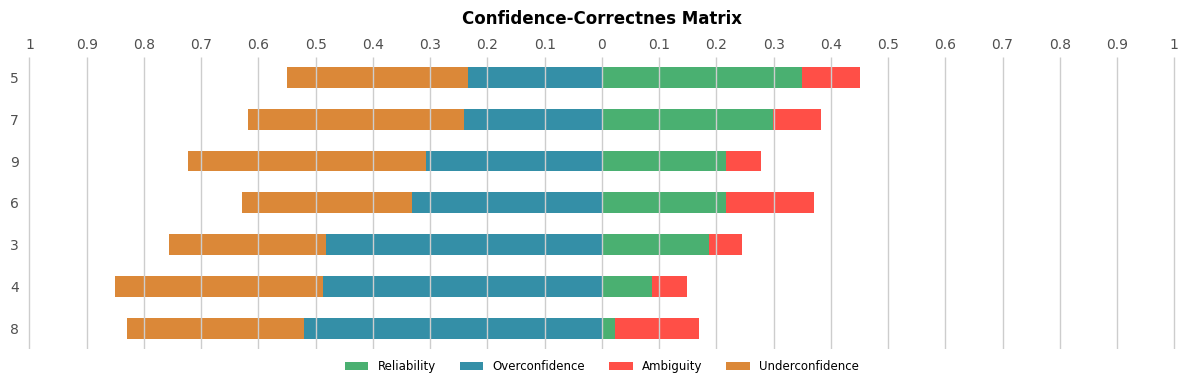

In [11]:
# Plots the class-dependent Confidence-Correctnes matrix
plot_confidence(y, y_score)